# About DATASET

## Titanic Dataset Variable Notes

---

### **SES (Socio-Economic Status)**

| Variable | Definition |
| --- | --- |
| **pclass** | A proxy for socio-economic status |
| 1st | **Upper** |
| 2nd | **Middle** |
| 3rd | **Lower** |

---

### **Demographics**

* **age**: Age is fractional if less than 1. If the age is estimated, it is in the form of `xx.5`.

---

### **Family Relations**

The dataset defines family relations in the following way:

* **sibsp (Siblings / Spouses)**
* **Sibling**: Brother, sister, stepbrother, stepsister.
* **Spouse**: Husband, wife (mistresses and fiancés were ignored).


* **parch (Parents / Children)**
* **Parent**: Mother, father.
* **Child**: Daughter, son, stepdaughter, stepson.
* **Note**: Some children travelled only with a nanny; therefore, `parch=0` for them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv')
df.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
614,615,0,3,"Brocklebank, Mr. William Alfred",male,35.0,0,0,364512,8.05,NaN,S


# Univriate analysis on Numerical columns

## Univariate analysis for Age

### conclusion
- Age is normally(almost) distributed
- 20% of value are missing
- There are some outliers

In [3]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: ylabel='Frequency'>

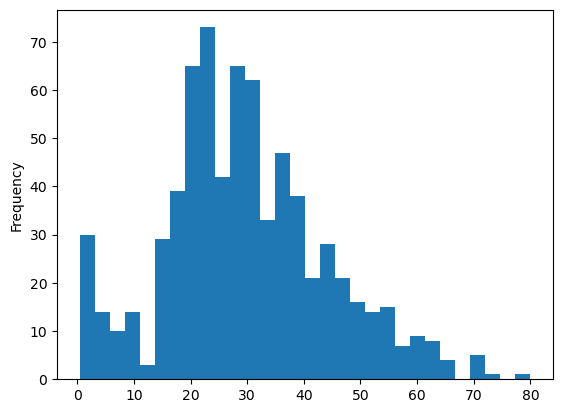

In [4]:
df['Age'].plot(kind='hist',bins=30)

<Axes: ylabel='Density'>

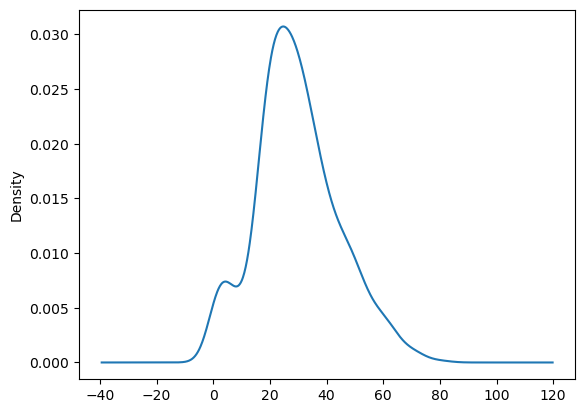

In [5]:
# it is approx to normal distribution
df['Age'].plot(kind='kde')

In [6]:
# if the number closed to 0 then it is a normal distribution
# if the number is +ve or -ve then it is +ve or -ve skewnees respectively
df['Age'].skew()

np.float64(0.38910778230082704)

<Axes: >

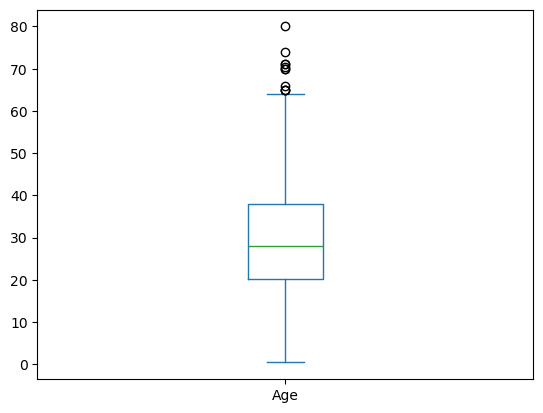

In [7]:
# we can see there is outlier
df['Age'].plot(kind='box')

In [8]:
# we must have to study outlier and remove if you find anything strange
df[df['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


it looks perfectly normal if there is age greater than 100 we can assume it as a outlier but it is perfectly fine.

In [9]:
# now we look for the missing value
( df["Age"].isnull().sum() ) / len(df["Age"]) * 100

np.float64(19.865319865319865)

We don't have around 19.8% of age data.

## Univariate analysis for Fair

**conclusions**

- The data is highly(positively) skewed
- Fare col actually contains the group fare and not the individual fare(This migth be and issue)
- We need to create a new col called individual fare

In [10]:
# we can see allmost 32$ has been paid for an avg seat in the titanic
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: ylabel='Frequency'>

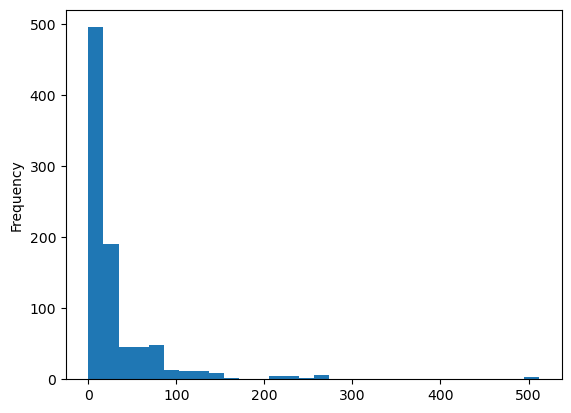

In [11]:
df['Fare'].plot(kind='hist',bins=30)

<Axes: ylabel='Density'>

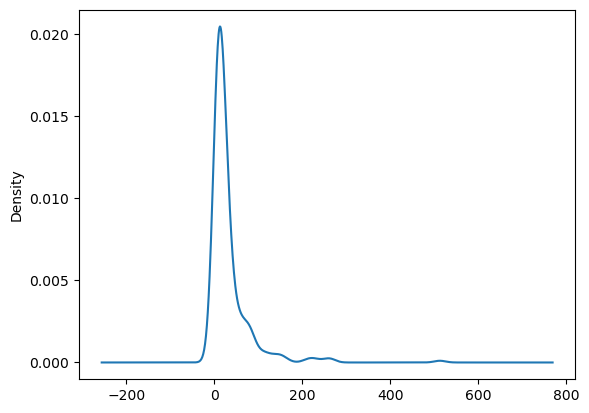

In [12]:
df['Fare'].plot(kind='kde')

In [13]:
# we can see that the data is +ve skew
df['Fare'].skew()

np.float64(4.787316519674893)

<Axes: >

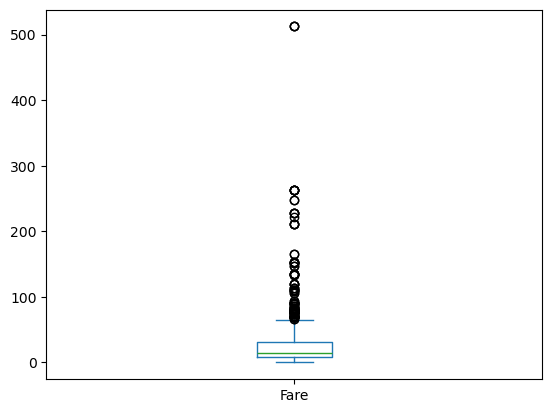

In [14]:
# it is +ve skew s we get lots of datapoints as outliers
df['Fare'].plot(kind='box')

In [15]:
# now we look for the missing value
( df["Fare"].isnull().sum() ) / len(df["Fare"]) * 100

np.float64(0.0)

# Univriate analysis on Categorical columns

### Steps of doing Univariate Analysis on Categorical columns

**Descriptive Statistics**: Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

**Visualizations**: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical data include count plots and pie charts. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the data.

**Missing Values**: Check for missing values in the data and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the data set.

**Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

## survived column-

**Conclusion**
- almost 38% survived

In [16]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived'>

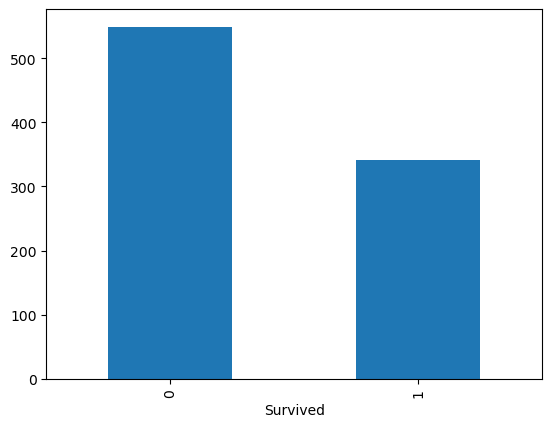

In [17]:
df['Survived'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

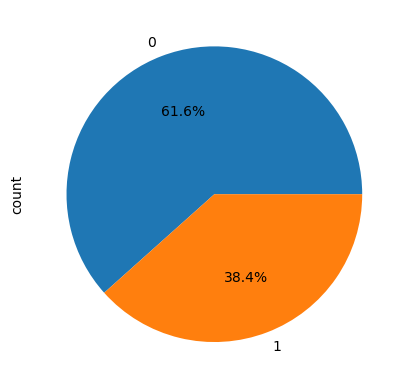

In [18]:
# Here is the breakdown of autopct in three simple points:
# Displays Percentages: It automatically calculates the proportion of each slice and displays it as a text label on the pie chart.
# Controls Precision: The 0.1f part determines the number of decimal places; in this case, it rounds the value to one decimal point (e.g., 38.4%).
# Handles Formatting: The % symbols at the start and end of the string act as a template to ensure a literal percentage sign is printed after the number.

df['Survived'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [19]:
# if has missing value
df['Survived'].isnull().sum()

np.int64(0)

## pclass

**conclusion**
- most of the passenger travel with lower class
- there is more upper class than middel class
- there is no null value

In [21]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass'>

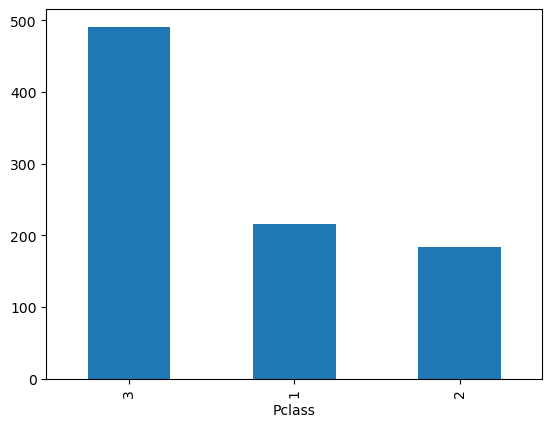

In [23]:
df['Pclass'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

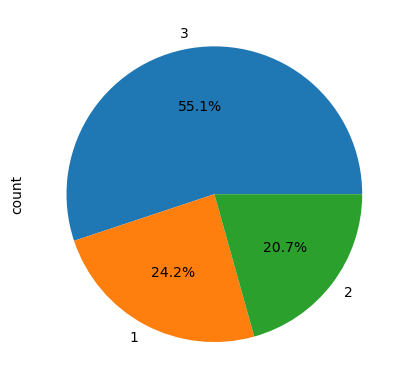

In [24]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [25]:
# if has missing value
df['Pclass'].isnull().sum()

np.int64(0)

## Sex

In [26]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: ylabel='count'>

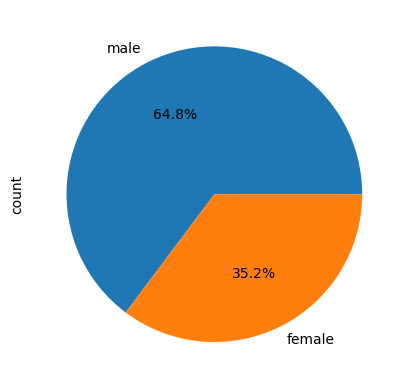

In [27]:
df['Sex'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [28]:
# if has missing value
df['Sex'].isnull().sum()

np.int64(0)

## SibSp

**Conclusion**
- There are more people travelling alone followed by single people

In [29]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp'>

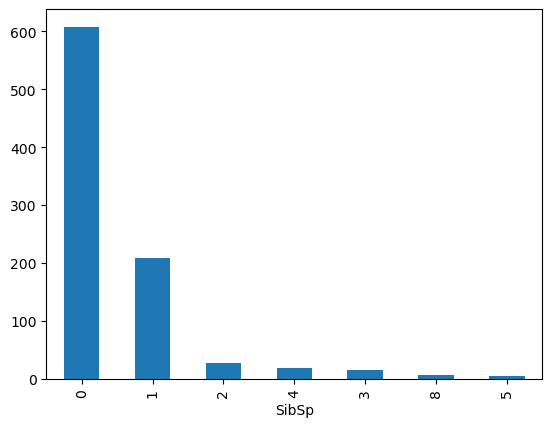

In [31]:
df['SibSp'].value_counts().plot(kind='bar')

In [32]:
# if has missing value
df['SibSp'].isnull().sum()

np.int64(0)

## Parch

**Conclusion**
- we don't need two column `SibSp` and `Parch` insted we make family_size
- create new column is_alone

In [35]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch'>

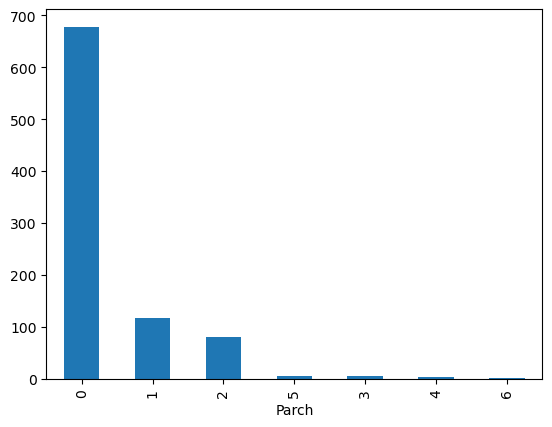

In [36]:
df['Parch'].value_counts().plot(kind='bar')

In [37]:
# if has missing value
df['Parch'].isnull().sum()

np.int64(0)

## Embarked

**Conclusion**
- maximum people inboarded from S
- There are two values missing

In [38]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: ylabel='count'>

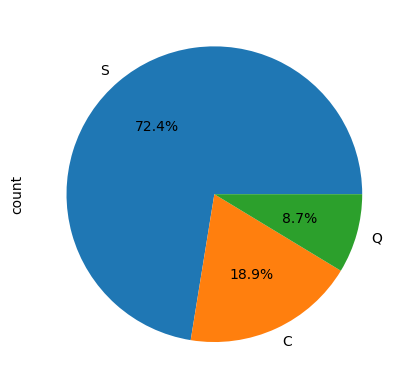

In [39]:
df['Embarked'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [40]:
# if has missing value
df['Embarked'].isnull().sum()

np.int64(2)

# Bivariate Analysis Categorical vs Categorical

- since we are building around the survived column, and age column is also one of the major column which affect the survival rate so we can do bivariate analysis of both with columns

## Survived vs pclass

**conclusion**
- we can see that the most safest class in 1 class
- and most denger class is 3 class
- 75% people dies in 3 class

In [41]:
# we can make contingency tables for the categorical vs categorical data
pd.crosstab(df["Survived"], df["Pclass"])

Pclass,1,2,3
Survived,,,
0,80,97,372
1,136,87,119


In [43]:
# we can also convert it to percentage
pd.crosstab(df["Survived"], df["Pclass"], normalize='columns') * 100

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


<Axes: xlabel='Pclass', ylabel='Survived'>

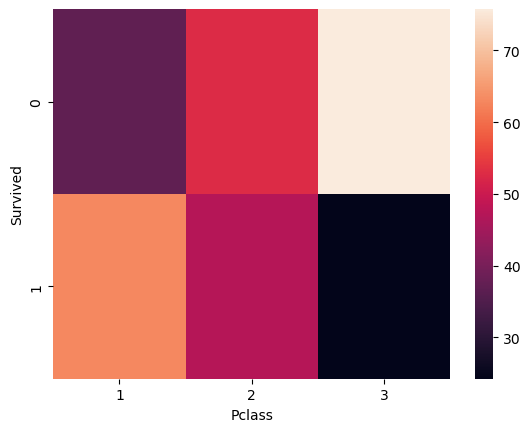

In [44]:
# we can also make heatmap for that
sns.heatmap( pd.crosstab(df["Survived"], df["Pclass"], normalize='columns') * 100 )

## Survived vs sex

**conclusion**
- you have more survival rate if you are female than male

In [47]:
temp_df = pd.crosstab(df["Survived"], df["Sex"], normalize='columns') * 100
temp_df

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


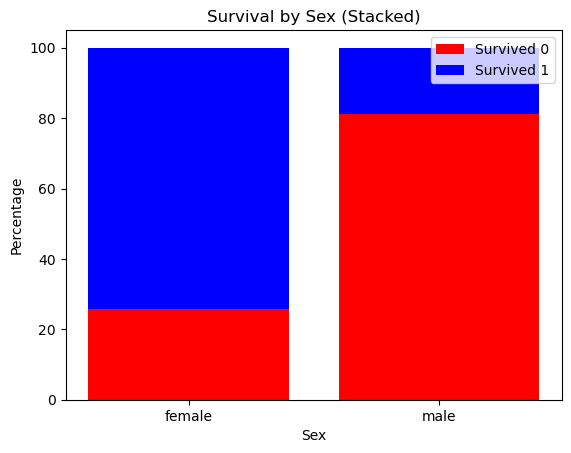

In [52]:
# Stacked Barplot
# 1. Plot the first layer (Survived 0)
plt.bar(temp_df.columns, temp_df.iloc[0], color='r', label='Survived 0')

# 2. Plot the second layer (Survived 1) on top of the first
# The 'bottom' parameter tells matplotlib where to start the blue bars
plt.bar(temp_df.columns, temp_df.iloc[1], bottom=temp_df.iloc[0], color='b', label='Survived 1')

# 3. Add styling
plt.xlabel('Sex')
plt.ylabel('Percentage')
plt.title('Survival by Sex (Stacked)')
plt.legend()
plt.show()

## Survived vs Embarked

**Conclusion**
- The C station is where the most people survived
- Most 1 class passenger deported from station C thats why.

In [53]:
pd.crosstab(df["Survived"], df["Pclass"], normalize='columns') * 100

Pclass,1,2,3
Survived,,,
0,37.037037,52.717391,75.763747
1,62.962963,47.282609,24.236253


In [54]:
pd.crosstab(df["Survived"], df["Embarked"], normalize='columns') * 100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


In [58]:
# so for our conclusion what the relationship Survived vs Embarked we check sex vs embarked and pclass vs embarked
pd.crosstab(df["Sex"], df["Embarked"], normalize='columns') * 100

Embarked,C,Q,S
Sex,,,
female,43.452381,46.753247,31.521739
male,56.547619,53.246753,68.478261


In [59]:
# we can clearly see that most 1 class passenger come from station c
pd.crosstab(df["Pclass"], df["Embarked"], normalize='columns') * 100

Embarked,C,Q,S
Pclass,,,
1,50.595238,2.597403,19.720497
2,10.119048,3.896104,25.465839
3,39.285714,93.506494,54.813665


# Bivariate Analysis Categorical vs Numerical

## survived and age

**Conclusion**
- we can there is slightly survided column upward when your age between 0-10(approx)
- from 20 to 40 you have higher probablity to die
- we are seeing a survided line very slightly upwared from age 38 - 42(approx) because the pcall memember has a mean age of 38
- There is very less change if your age is above 60. 

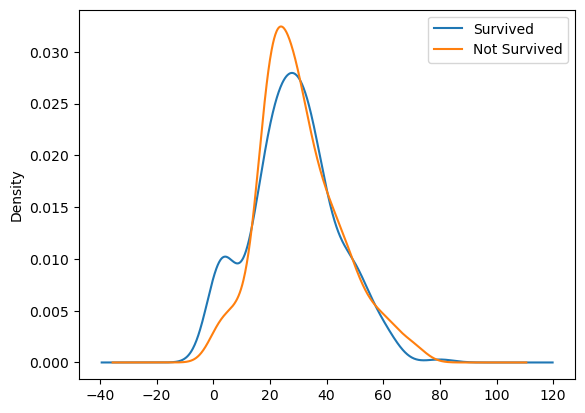

In [61]:
df[df['Survived'] == 1]['Age'].plot(kind='kde',label='Survived')
df[df['Survived'] == 0]['Age'].plot(kind='kde',label='Not Survived')

plt.legend()
plt.show()

In [64]:
# we can see avg mean of class 1
df[df['Pclass'] == 1]['Age'].mean()

np.float64(38.233440860215055)

# Feature engineering

- the data is split into train and test so we cannot able to get the full family name and because of that we cannot get the individual fare.
- So, We have to merge train and test to fetch all the members so we can divide and get the family_size

In [88]:
df_test = pd.read_csv('test.csv')
df_total = pd.concat([df,df_test])
df.shape

(891, 12)

## Family size

In [89]:
df_total['family_size'] = df_total['SibSp'] + df_total['Parch'] + 1

## Individual Fare

- Formula is individual Fare = Fare / Family_size

In [90]:
# lets see sibsp which has how many sib and parents
df_total['SibSp'].value_counts()

SibSp
0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64

In [91]:
# lets wee want to see for ticked
# we can see there is 11 members which is equal to family_size
df_total[df_total['Ticket'] == 'CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S,11
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S,11
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S,11
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S,11


In [92]:
df_total['individual_fare'] = df_total['Fare']/df_total['family_size']
df_total.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,individual_fare
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,3.62500
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,35.64165
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,7.92500
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.55000
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,8.05000


## Family Type

**family_type**
1. alone (1)
2. small (2-4)
3. large (>5)

In [93]:
def transform_family_type(n):
    if n == 1:
        return 'alone'
    elif n > 1 and n < 5:
        return 'small'
    else:
        return 'large'
df_total['family_type'] = df_total['family_size'].apply(transform_family_type)
df_total.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,individual_fare,family_type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,3.62500,small
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,35.64165,small
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,7.92500,alone
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,26.55000,small
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,8.05000,alone


In [103]:
df_total[df_total['Name'].str.contains('Eva')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,family_size,individual_fare,family_type
535,536,1.0,2,"Hart, Miss. Eva Miriam",female,7.0,0,2,F.C.C. 13529,26.2500,NaN,S,3,8.75000,small
32,924,NaN,3,"Dean, Mrs. Bertram (Eva Georgetta Light)",female,33.0,1,2,C.A. 2315,20.5750,NaN,S,4,5.14375,small
112,1004,NaN,1,"Evans, Miss. Edith Corse",female,36.0,0,0,PC 17531,31.6792,A29,C,1,31.67920,alone
147,1039,NaN,3,"Davies, Mr. Evan",male,22.0,0,0,SC/A4 23568,8.0500,NaN,S,1,8.05000,alone
